In [1]:
import pandas as pd
import re
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix


In [2]:
df = pd.read_csv("twitter.csv")
print(df.columns)
print(df.head())


Index(['id', 'user_posted', 'name', 'description', 'date_posted', 'photos',
       'url', 'tagged_users', 'replies', 'reposts', 'likes', 'views',
       'external_url', 'hashtags', 'followers', 'biography', 'posts_count',
       'profile_image_link', 'following', 'is_verified', 'quotes', 'bookmarks',
       'parent_post_details', 'external_image_urls', 'videos', 'quoted_post'],
      dtype='object')
                    id   user_posted           name  \
0  1868428607451799983  Glo███ews███   Glo███ews███   
1  1868159094567121215  bil███ard███   bil███ard███   
2  1868451534708883739  TNT███rts███  TNT███ort███R   
3  1868441382022717466  TNT███rts███  TNT███ort███R   
4  1868418260892565925  Glo███ews███   Glo███ews███   

                                         description  \
0  Com o fim da ditadura Assad, muitos sírios con...   
1  Brian Austin Green Tells MGK to ‘Grow Up’ Afte...   
2  VENCE O PSG NO CLÁSSICO! 💪🇫🇷 Nossa @claalbuque...   
3  ÍDOLO E AGORA PRESIDENTE! 🇦🇷🇦🇷 O ex-ata

In [3]:
def clean_text(text):
    text = str(text).lower()
    text = re.sub(r"http\S+|www\S+|https\S+", '', text)   # remove URLs
    text = re.sub(r'@\w+|#','', text)                    # remove mentions/hashtags
    text = re.sub(r'[^a-zA-Z\s]', '', text)              # remove punctuation/special chars
    text = re.sub(r'\s+', ' ', text).strip()             # remove extra spaces
    return text

df['clean_text'] = df['description'].astype(str).apply(clean_text)


In [4]:
hate_keywords = ['hate', 'kill', 'stupid', 'idiot', 'racist', 'terrorist']
df['label'] = df['clean_text'].apply(
    lambda x: 1 if any(word in x for word in hate_keywords) else 0
)


In [5]:
X = df['clean_text']
y = df['label']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)


In [6]:
vectorizer = TfidfVectorizer(stop_words='english', max_features=5000)
X_train_tfidf = vectorizer.fit_transform(X_train)
X_test_tfidf = vectorizer.transform(X_test)


In [7]:
clf = DecisionTreeClassifier(random_state=42)
clf.fit(X_train_tfidf, y_train)


,criterion,'gini'
,splitter,'best'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,42
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


In [8]:
y_pred = clf.predict(X_test_tfidf)


In [11]:
# Evaluation
print("Accuracy:", accuracy_score(y_test, y_pred))

# Ensure labels are integers for report
y_test = y_test.astype(int)
y_pred = y_pred.astype(int)

print("\nClassification Report:\n", classification_report(y_test, y_pred, zero_division=0))



Accuracy: 0.995

Classification Report:
               precision    recall  f1-score   support

           0       0.99      1.00      1.00       199
           1       0.00      0.00      0.00         1

    accuracy                           0.99       200
   macro avg       0.50      0.50      0.50       200
weighted avg       0.99      0.99      0.99       200



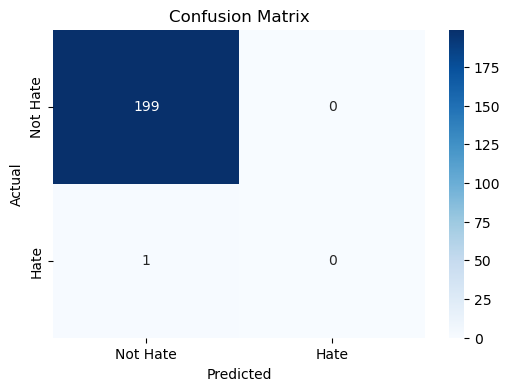

In [10]:
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Not Hate', 'Hate'],
            yticklabels=['Not Hate', 'Hate'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()
